## GPR on WeatherBench Data 
Apply GP regression baseline (using exact GP to train on monthly data)

In [1]:
# Check GPU
!nvidia-smi

Fri Feb 21 17:08:26 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.14              Driver Version: 550.54.14      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla V100-PCIE-16GB           Off |   00000000:1A:00.0 Off |                    0 |
| N/A   32C    P0             26W /  250W |       0MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import seaborn as sns
import pickle
import time
from tqdm.notebook import tqdm

import torch
from torch.utils.data import TensorDataset, DataLoader

import gpytorch

import geometric_kernels
import geometric_kernels.torch 
from geometric_kernels.spaces import Hypersphere
from geometric_kernels.kernels import MaternGeometricKernel
from geometric_kernels.frontends.gpytorch import GPyTorchGeometricKernel

INFO (geometric_kernels): Numpy backend is enabled. To enable other backends, don't forget to `import geometric_kernels.*backend name*`.
INFO (geometric_kernels): We may be suppressing some logging of external libraries. To override the logging policy, call `logging.basicConfig`.
INFO (geometric_kernels): Torch backend enabled.


In [3]:
torch.set_default_dtype(torch.float64)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


Monkey patching: Geometric_kernel package uses numpy for computations behind the scene. This causes the "tensors not on the same device" problem. 

In [5]:
import geometric_kernels.kernels.karhunen_loeve as kl
import geometric_kernels.spaces.hypersphere as spaces

def new_spectrum(s, nu, lengthscale, dimension):

    assert lengthscale.shape == (1,)
    assert nu.shape == (1,)

    s_tensor = torch.as_tensor(s, dtype=lengthscale.dtype, device=lengthscale.device)
    # Replace np.r_[1.0] with a torch tensor on the correct device
    one_tensor = torch.tensor([1.0], dtype=lengthscale.dtype, device=lengthscale.device)
    # Compute safe_nu: if nu == inf, use 1.0; otherwise keep nu
    safe_nu = torch.where(nu == np.inf, one_tensor, nu)
    # For nu == inf: compute spectral values
    spectral_values_nu_infinite = torch.exp(- (lengthscale**2) / 2.0 * s_tensor).to(device)
    
    # For nu < inf: compute spectral values
    power = -safe_nu - dimension / 2.0
    base = 2.0 * safe_nu / (lengthscale**2) + s_tensor
    spectral_values_nu_finite = base ** power
    
    return torch.where(nu == np.inf, spectral_values_nu_infinite, spectral_values_nu_finite)


def patched_addition_theorem(self, X, X2=None, **kwargs):
    # Determine target device from input X (assumes X is a tensor)
    device = X.device if hasattr(X, "device") else torch.device("cuda")
    # Compute the values and force them to the target device
    values = [
        level.addition(X, X2)[..., None].to(device)  # [N, N2, 1]
        for level in self._spherical_harmonics.harmonic_levels
    ]
    # Concatenate along the last dimension; using torch.cat here
    return torch.cat(values, dim=-1)  # [N, N2, L]

# Apply the monkey patch
kl.MaternKarhunenLoeveKernel.spectrum = staticmethod(new_spectrum)
spaces.SphericalHarmonics._addition_theorem = patched_addition_theorem

In [6]:
def to_pickle(obj, fn):
    with open(fn, 'wb') as f:
        pickle.dump(obj, f)
def read_pickle(fn):
    with open(fn, 'rb') as f:
        return pickle.load(f)

In [7]:
def compute_weighted_mae(da_fc, da_true, mean_dims=xr.ALL_DIMS):
    """ Stolen from WeatherBench score.py
    Compute the MAE with latitude weighting from two xr.DataArrays.
    Args:
        da_fc (xr.DataArray): Forecast. Time coordinate must be validation time.
        da_true (xr.DataArray): Truth.
        mean_dims: dimensions over which to average score
    Returns:
        mae: Latitude weighted root mean absolute error
    """
    error = da_fc - da_true
    weights_lat = np.cos(np.deg2rad(error.lat))
    weights_lat /= weights_lat.mean()
    mae = (np.abs(error) * weights_lat).mean(mean_dims)
    return mae

def compute_weighted_rmse(da_fc, da_true, mean_dims=xr.ALL_DIMS):
    """ Stolen from WeatherBench score.py
    Compute the RMSE with latitude weighting from two xr.DataArrays.

    Args:
        da_fc (xr.DataArray): Forecast. Time coordinate must be validation time.
        da_true (xr.DataArray): Truth.
        mean_dims: dimensions over which to average score
    Returns:
        rmse: Latitude weighted root mean squared error
    """
    error = da_fc - da_true
    weights_lat = np.cos(np.deg2rad(error.lat))
    weights_lat /= weights_lat.mean()
    rmse = np.sqrt(((error)**2 * weights_lat).mean(mean_dims))
    return rmse

## Data Processing

Loading the data

In [8]:
z500 = xr.open_mfdataset('data/5.625deg/geopotential_500/*.nc', combine='by_coords')
z500_train = z500.sel(time=slice('2017.12', '2017.12'))['z']
z500_test = z500.sel(time=slice('2018', '2018.1'))['z'] # 2017-2018 data

In [9]:
data_mean = z500_train.mean().load()
data_std = z500_train.std().load()

# Normalize datasets
data_train = (z500_train - data_mean) / data_std
data_test = (z500_test - data_mean) / data_std

We need to convert (lat., lon.) coordinates into (x,y,z) for the inputs into the spatial kernel from GeometricKernel 

In [10]:
def latlon_to_cartesian(lat, lon, device=device):
    """ Converting (lat., lon.) to cartesian coordinates on a unit sphere
        Note: WeatherBench data is defined on a constant altitude """

    lat, lon = np.deg2rad(lat), np.deg2rad(lon)

    x = np.cos(lat)[:, None] * np.cos(lon)[None, :]
    y = np.cos(lat)[:, None] * np.sin(lon)[None, :]
    z = np.sin(lat)[:, None] * np.ones_like(lon)[None, :]

    xyz = np.stack([x, y, z], axis=-1)  # Out: (nlat, nlon, 3)
    return torch.tensor(xyz).to(device)

Subsampling the datasets due to memory issues

In [11]:
def create_training_data(data_train, data_test, lead_time_h, space_subsample, time_subsample, device=device, train=True):
    """Preparing input and output data. X should be the coordinate input into the kernel, 
    while Y should be the forecast target (shifted lead time)."""

    # Training Data
    X = data_train.isel(time=slice(0, -lead_time_h, time_subsample),
                        lat=slice(0, None, space_subsample),
                        lon=slice(0, None, space_subsample))
    Y = data_train.isel(time=slice(lead_time_h, None, time_subsample),
                  lat=slice(0, None, space_subsample),
                  lon=slice(0, None, space_subsample))
    

    # Preparing the input coords (should have shape (ntime, nlat, nlon, 4) if we have no subsampling)
    X_time = (X.time - data_train.time[0]).values / np.timedelta64(1, 'h')
    X_time = torch.tensor(X_time).to(device)
    t_steps = X_time.shape[0]

    latitudes = X.lat.values 
    longitudes = X.lon.values 
    cartesian_coords = latlon_to_cartesian(X.lat.values, X.lon.values, device)
    nlat, nlon, _ = cartesian_coords.shape

    # Testing Data
    X_test = data_test.isel(time=slice(0, -lead_time_h, time_subsample),
                        lat=slice(0, None, space_subsample),
                        lon=slice(0, None, space_subsample))
    Y_test = data_test.isel(time=slice(lead_time_h, None, time_subsample),
                  lat=slice(0, None, space_subsample),
                  lon=slice(0, None, space_subsample))
    X_test_time = (X_test.time - data_train.time[0]).values / np.timedelta64(1, 'h')
    X_test_time = torch.tensor(X_test_time).to(device)
    test_t_steps = X_test_time.shape[0]

    if train:
        print("Processing Training Dataset")
        # Combine spatial and temporal data
        combined_coords = torch.empty((t_steps, nlat, nlon, 4)).to(device)
        # Fill in the spatial part first
        combined_coords[..., :3] = cartesian_coords.unsqueeze(0).expand(t_steps, -1, -1, -1)
        # The final element is time
        combined_coords[..., 3] = X_time.view(t_steps, 1, 1).expand(t_steps, nlat, nlon)
        # Flatten combined_coords to get GP input of shape (N, 4)
        combined_coords = combined_coords.view(-1, 4)
        X_size = combined_coords.element_size() * combined_coords.nelement() / (1024**2)
        print(f"Combined coords info --> Shape: {combined_coords.shape}, Mem: {X_size:.2f} MB")

        # Flatten to shape (N,)
        Y = torch.tensor(Y.values).view(-1).to(device)
        Y_size = Y.element_size() * Y.nelement() / (1024**2)
        print(f"Target info --> Shape: {Y.shape}, Mem: {Y_size:.2f} MB")

        return combined_coords, Y
    
    else:
        print("Processing Test Dataset")
        # Combine spatial and temporal data
        combined_coords = torch.empty((test_t_steps, nlat, nlon, 4)).to(device)
        # Fill in the spatial part first
        combined_coords[..., :3] = cartesian_coords.unsqueeze(0).expand(test_t_steps, -1, -1, -1)
        # The final element is time
        combined_coords[..., 3] = X_test_time.view(test_t_steps, 1, 1).expand(test_t_steps, nlat, nlon)
        # Flatten combined_coords to get GP input of shape (N, 4)
        combined_coords = combined_coords.view(-1, 4)
        X_size = combined_coords.element_size() * combined_coords.nelement() / (1024**2)
        print(f"Combined coords info --> Shape: {combined_coords.shape}, Mem: {X_size:.2f} MB")

        # Flatten to shape (N,)
        Y_test = torch.tensor(Y_test.values).view(-1).to(device)
        Y_size = Y_test.element_size() * Y_test.nelement() / (1024**2)
        print(f"Target info --> Shape: {Y_test.shape}, Mem: {Y_size:.2f} MB")

        return combined_coords, Y_test, latitudes, longitudes

## Defining the Kernel

We work on the 2d-hypersphere, modeling the spatial kernel with Geometric_Kernel and time kernel with periodic kernel. 

In [12]:
# Spatial Kernel from Geometric_Kernel package
sphere = Hypersphere(dim=2)
# Matern Kernel
spatial_kernel_gm = MaternGeometricKernel(sphere)
params = spatial_kernel_gm.init_params()
# Set params here, we want to work with Matern-3/2 (or 5/2)
params["lengthscale"] = torch.tensor([0.5]).to(device)
params["nu"] = torch.tensor([3/2]).to(device)
print('params:', params)

params: {'nu': tensor([1.5000], device='cuda:0'), 'lengthscale': tensor([0.5000], device='cuda:0')}


In [13]:
# Define the GP regression kernel, separable in space and time
# First convert Geometric Kernel to a GPyTorch compatible kernel
spatial_kernel = gpytorch.kernels.ScaleKernel(
                    GPyTorchGeometricKernel(
                        spatial_kernel_gm,
                        nu = params["nu"],
                        lengthscale=params["lengthscale"],
                        trainable_nu=False,
                        active_dims=[0,1,2]
                    )
                ).to(device)
# spatial_kernel.outputscale = 1.0 #Fix the scale of cov function

# For temporal kernel
time_kernel1 = gpytorch.kernels.PeriodicKernel(period_length=24, active_dims=[3]).to(device) # Daily    
time_kernel2 = gpytorch.kernels.PeriodicKernel(period_length=24*7, active_dims=[3]).to(device) # Weekly
time_kernel3 = gpytorch.kernels.PeriodicKernel(period_length=24*30, active_dims=[3]).to(device) # Monthly
time_kernel = time_kernel1 + time_kernel2 + time_kernel3

# Construct the product kernel
kernel = spatial_kernel * time_kernel

class GPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(GPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean() 
        self.covar_module = kernel

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

## Training and Evaluation

In [14]:
def train_gp(lead_time_h, data_train, data_test, space_subsample, time_subsample, epochs=200, save_model=False, device=device):
    """
    Train a Gaussian Process model using GPyTorch. Can add subsampling the data for efficiency.
    """
    
    # Prepare training data
    X_train, Y_train = create_training_data(data_train, data_test, lead_time_h, space_subsample=space_subsample, 
                                                  time_subsample=time_subsample, device=device)

    likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)
    model = GPModel(X_train, Y_train, likelihood).to(device)
    
    # Train model
    model.train()
    likelihood.train()

    # Optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=0.1) 
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.99)

    # Loss fn
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    # Training loop
    print("Starting Exact GP regression training on a single month:")
    # Reset the peak memory statistics before training
    torch.cuda.reset_peak_memory_stats(device)
    start_time = time.time()

    loss_history = []
    with tqdm(total=epochs, desc="Training Progress", unit="epoch") as pbar:
        for i in range(epochs):
            optimizer.zero_grad()
            output = model(X_train)
            loss_val = -mll(output, Y_train)
            loss_val.backward()
            loss_history.append(loss_val.item())
            optimizer.step()
            pbar.set_postfix(loss=f"{loss_val.item():.3f}")
            pbar.update(1)

    current_allocated = torch.cuda.memory_allocated(device)
    max_allocated = torch.cuda.max_memory_allocated(device)
    print(f"Current GPU memory allocated: {current_allocated / (1024**2):.2f} MB")
    print(f"Peak GPU memory allocated: {max_allocated / (1024**2):.2f} MB")

    end_time = time.time()
    print("Training completed")
    time_elapsed = end_time - start_time
    print(f"Training time: {time_elapsed:.2f}s")

    X_test, Y_test, lat, lon = create_training_data(data_train, data_test, lead_time_h, space_subsample=space_subsample, 
                                                  time_subsample=time_subsample, device=device, train=False)

    # Save model
    if save_model:
        torch.save(model.state_dict(), "gp_model.pth")
        torch.save(likelihood.state_dict(), "gp_likelihood.pth")
        print("Saved model")

    return model, likelihood, loss_history, X_test, Y_test, lat, lon

In [15]:
lead_time = 3*24
space_subsample = 5 # Sub-sample every 5th point
time_subsample = 12 # Sub-sample every 12th hour
# Train GP model
model, likelihood, loss, X_test, Y_test, lat, lon = train_gp(lead_time, data_train, data_test, space_subsample, time_subsample)

Processing Training Dataset
Combined coords info --> Shape: torch.Size([5096, 4]), Mem: 0.16 MB
Target info --> Shape: torch.Size([5096]), Mem: 0.02 MB
Starting Exact GP regression training on a single month:


Training Progress:   0%|          | 0/200 [00:00<?, ?epoch/s]

Current GPU memory allocated: 216.15 MB
Peak GPU memory allocated: 10124.60 MB
Training completed
Training time: 228.63s
Processing Test Dataset
Combined coords info --> Shape: torch.Size([5096, 4]), Mem: 0.16 MB
Target info --> Shape: torch.Size([5096]), Mem: 0.02 MB


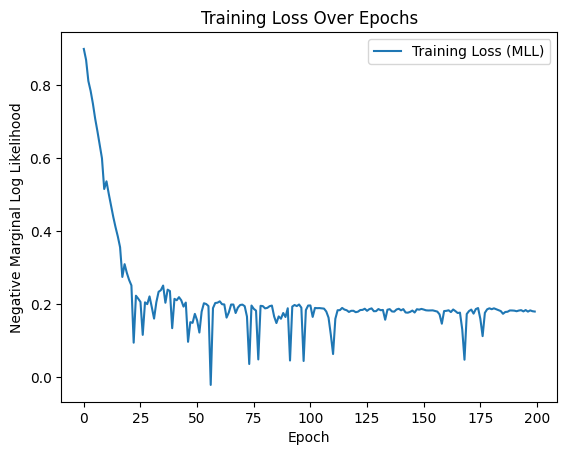

In [16]:
# Plot the loss
plt.plot(loss, label='Training Loss (MLL)')
plt.xlabel("Epoch")
plt.ylabel("Negative Marginal Log Likelihood")
plt.title("Training Loss Over Epochs")
plt.legend()
plt.show()

In [17]:
t_steps = int(X_test.shape[0] / (len(lat) * len(lon)))
nlat = len(lat)
nlon = len(lon)

# Make Predictions
model.eval()
likelihood.eval()

with torch.no_grad():
    pred_dist = model(X_test)
    Y_pred = pred_dist.mean  

mse = torch.mean((Y_pred - Y_test)**2)
rmse = torch.sqrt(mse)
print("RMSE:", rmse.item())

RMSE: 0.2801999018767979
